In [1]:
import numpy as np
from tqdm.auto import tqdm

from utils.plot import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

Using PyTorch version: 1.12.0, Device: cpu


In [9]:
# ----- Utils -----

In [10]:
def train(model, train_loader, optimizer, scheduler = None):
    model.train()
    train_loss = 0
    correct = 0
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        train_loss += loss.item()
        prediction = output.max(1, keepdim = True)[1]
        correct += prediction.eq(label.view_as(prediction)).sum().item()
        optimizer.step() # parameter update
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))
    if scheduler is not None:
        scheduler.step() # lr update
    train_loss /= len(train_loader.dataset)
    train_acc = 100. * correct / len(train_loader.dataset)
    return train_loss, train_acc

def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    return test_loss, test_acc

In [3]:
# ----- Load Fashion MNIST -----

In [4]:
BATCH_SIZE = 1024

train_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])), # train data에서 흑,백의 평균값이 0.1307, 0.3081 -> mean centered
                          batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=False,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])),
                          batch_size=BATCH_SIZE, shuffle=True)

FashionMNIST_plot_dataset(train_loader)

/Users/jeongmoonwon/opt/anaconda3/lib/python3.8/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:178.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


In [5]:
# ----- Model -----

In [6]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=8),
            nn.ReLU(),
            nn.nn.dropout(p=0.3),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 10),
        )
    
    def forward(self,x):
        x = self.conv(x)
        return x

In [7]:
# ----- Custom Learning Rate Scheduler -----

In [8]:
class ScheduledOptim():

    def __init__(self, optimizer, n_warmup_steps, decay_rate, steps=None):
        self._optimizer = optimizer
        self.n_warmup_steps = n_warmup_steps # 처음에 lr를 0부터 initial lr까지 몇 스텝동안 올릴 것인지
        self.decay = decay_rate # lr를 얼만큼의 비율로 줄여나갈 것인지
        self.n_steps = 0 # 현재 몇번째 epoch에 있는지
        self.steps = steps # lr decay를 매 epoch마다가 아니라 계단식으로 하고 싶은 경우
        self.initial_lr = optimizer.param_groups[0]['lr']
        self.current_lr = optimizer.param_groups[0]['lr']

    def zero_grad(self):
        self._optimizer.zero_grad() # 미니재치 돌 때마다 gradient를 0으로 initialize. -> optimizer.zero_grad() 대신 사용

    def step(self):
        self.update() # self._optimizer.step()과 같은 동작을 함. -> optimizer.step() 대신 사용
    
    def get_lr(self):
        return self.current_lr # optimizer.param_groups[0]['lr'] 대신 사용
    
    def update(self):
        if self.n_steps < self.n_warmup_steps: # 계속해서 lr 올리기
            lr = (self.n_steps / self.n_warmup_steps) * self.initial_lr
        elif self.n_steps == self.n_warmup_steps:
            lr = self.initial_lr
        else:
            if self.steps is None: # 연속적으로 decay
                lr = self.current_lr * self.decay
            else: # 계단식으로 decay
                if self.n_steps in self.steps:
                    lr = self.current_lr * self.decay
                else:
                    lr = self.current_lr
        
        self.current_lr = lr
        
        for param_groups in self._optimizer.param_groups: # 실제로 optimizer에 적용
            param_groups['lr'] = lr

        self.n_steps += 1



[EPOCH: 1], 	LR: 0.00000, 	Train Loss: 0.0023, 	Train Accuracy: 8.00 %, 	Test Loss: 0.0023, 	Test Accuracy: 8.01 % 





[EPOCH: 2], 	LR: 0.00033, 	Train Loss: 0.0007, 	Train Accuracy: 73.75 %, 	Test Loss: 0.0005, 	Test Accuracy: 83.20 % 





[EPOCH: 3], 	LR: 0.00067, 	Train Loss: 0.0004, 	Train Accuracy: 84.94 %, 	Test Loss: 0.0004, 	Test Accuracy: 86.14 % 





[EPOCH: 4], 	LR: 0.00100, 	Train Loss: 0.0004, 	Train Accuracy: 86.88 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.14 % 





[EPOCH: 5], 	LR: 0.00100, 	Train Loss: 0.0003, 	Train Accuracy: 88.45 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.45 % 





[EPOCH: 6], 	LR: 0.00050, 	Train Loss: 0.0003, 	Train Accuracy: 89.62 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.46 % 





[EPOCH: 7], 	LR: 0.00050, 	Train Loss: 0.0003, 	Train Accuracy: 90.23 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.81 % 





[EPOCH: 8], 	LR: 0.00025, 	Train Loss: 0.0002, 	Train Accuracy: 90.77 %, 	Test Loss: 0.0003, 	Test Accuracy: 90.11 % 





[EPOCH: 9], 	LR: 0.00025, 	Train Loss: 0.0002, 	Train Accuracy: 91.05 %, 	Test Loss: 0.0003, 	Test Accuracy: 90.33 % 





[EPOCH: 10], 	LR: 0.00025, 	Train Loss: 0.0002, 	Train Accuracy: 91.24 %, 	Test Loss: 0.0003, 	Test Accuracy: 90.45 % 



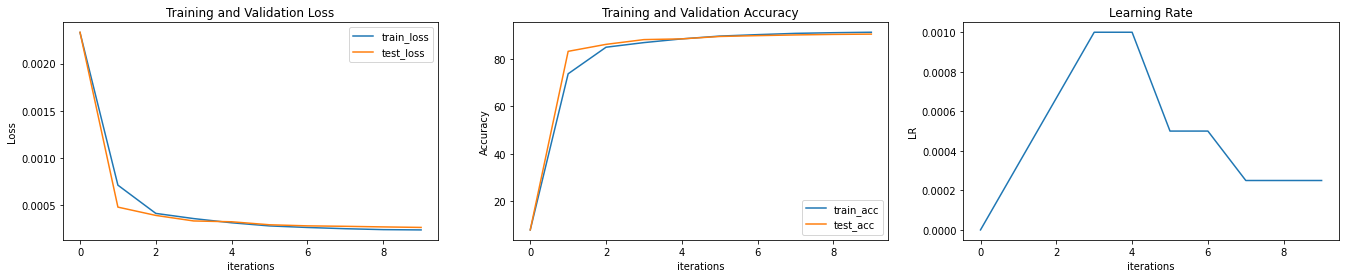

In [13]:
# train, test
EPOCHS = 10
best_loss = 1000
patience = 0
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ScheduledOptim(optimizer, n_warmup_steps=3, decay_rate=0.5, steps=[5,7])
criterion = nn.CrossEntropyLoss()

scheduler.update() # 이 코드를 실행하지 않는 경우 optimizer에 있는 initial lr(0.001)부터 시작하므로 lr를 0부터 증가시키는 warm-up을 할 수 없음

for epoch in range(1, EPOCHS + 1):
    lr = scheduler.get_lr()
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.5f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, lr, train_loss, train_accuracy, test_loss, test_accuracy))
    
    # test_loss가 증가하는 시점에서 early stopping
    if test_loss < best_loss:
        best_loss = test_loss
        patience = 0
    else:
        patience += 1
        if patience >= 2:
            break

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(lr)
    
plot_history(history)